# Bank_Market_Campaines

**Note:**
- In this experiment, we will perform several operations on a CSV file using the NumPy, Pandas, Matplotlib, Seaborn, and SKLearn libraries.
- Our primary focus will be on key operations commonly used in these libraries for building Logistic Regression models.
- The following operations will be conducted on the CSV file:

   - Importing the necessary libraries.
   - Loading the dataset for the experiment.
   - Understanding the data contained in the file.
   - Performing data cleaning and visualization operations.
   - Preparing the data for further processing within the Data Science Life Cycle.
   - Conducting Exploratory Data Analysis (EDA) on the processed data.
   - Building predictive models using the EDA-processed data.
   - Performing model evaluations.

**Experiment Link** --> https://colab.research.google.com/drive/1Wp0T5vob439L211LUYroHQuvnZ_sXjPM?usp=sharing

**Data set Link** --> https://drive.google.com/file/d/1HSlSCkV1f5qP7fO1a862PGzNiqMWxyHF/view?usp=sharing


### STEP 1. Problem Statement:
- We want to run a marketing campaign to find the right customers for our services and inform them about the new benefits provided by the bank.

### STEP 2.Importing the necessary libraries.


In [85]:
# Importing the required libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *

### STEP 3.Loading the Dataset into the Environment.

In [86]:
# Loading the dataset.
df = pd.read_csv("/content/bank-additional-full.csv",sep=';')

In [87]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,149.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,226.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,151.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,307.0,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [88]:
# Understanding the dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

In [89]:
df.shape

(41199, 21)

- Observing the data set for how many types of data are contained in the CSV_file.
- By this, we understand the dataset's composition and the different data types present in the file.

### STEP 4.Data Cleaning Operation performed on the dataset.

In [90]:
# checking for null values.
df.isnull().sum()

,0
age,4
job,5
marital,5
education,5
default,4
housing,3
loan,4
contact,4
month,3
day_of_week,3


In [91]:
df.isnull().sum().sum()

np.int64(76)

In [92]:
# We are removing the null values from the dataset.
df.dropna(inplace=True)

In [93]:
# Checking for Duplicate Values.
df.duplicated().sum()

np.int64(13)

In [94]:
# Removing the duplicated values.
df.drop_duplicates(inplace=True)

### STEP 5.Exploratory Data Analysis(EDA)
- For checking and removing the unwanted and irrelevant data in the dataset.


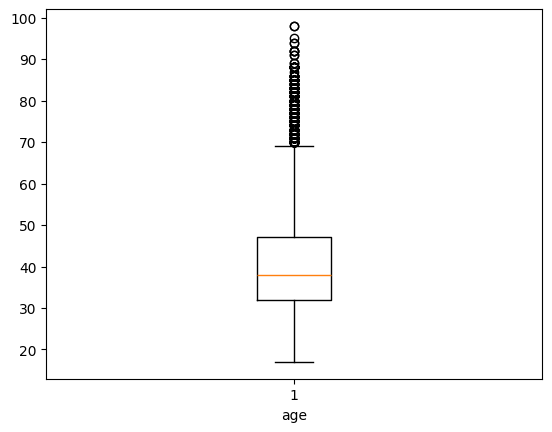

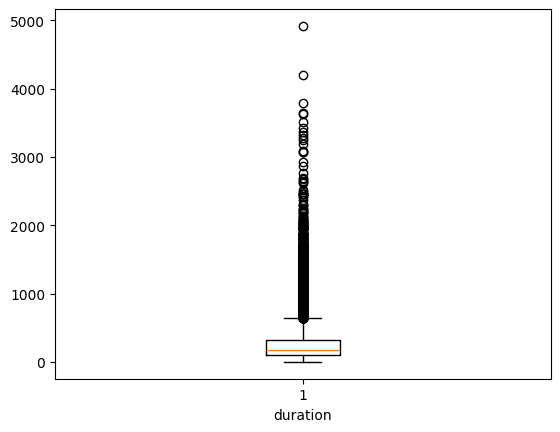

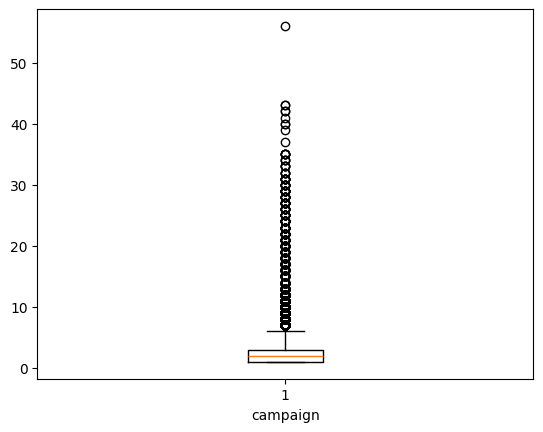

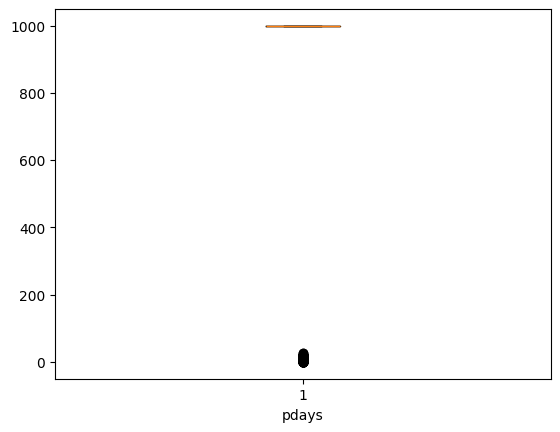

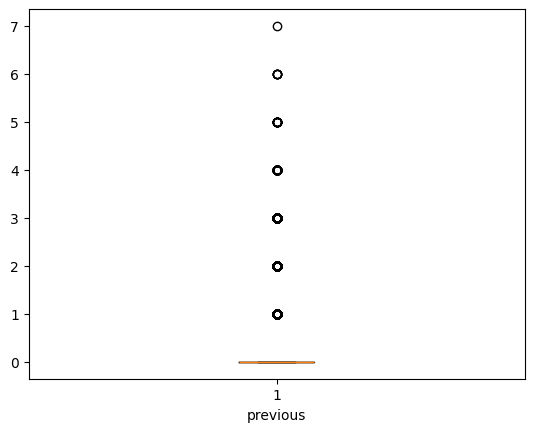

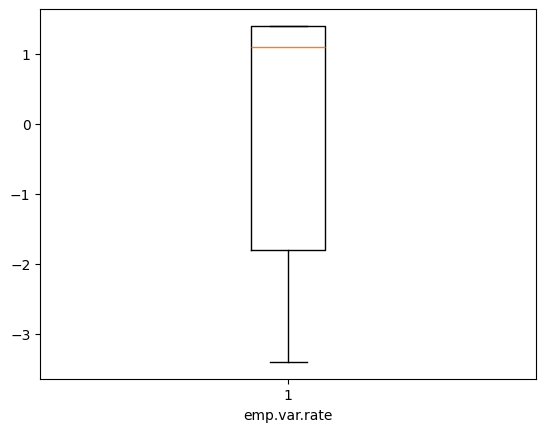

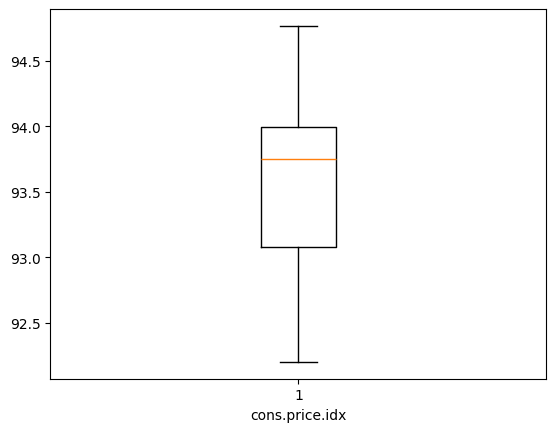

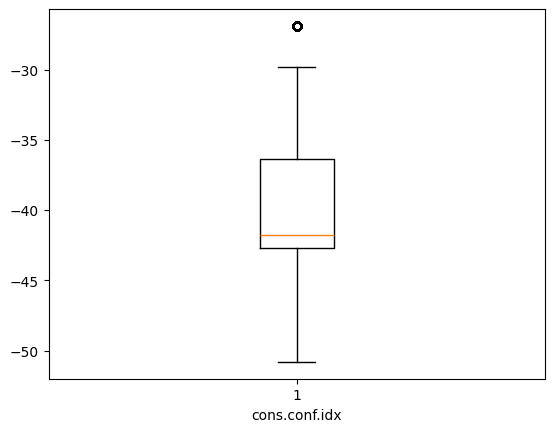

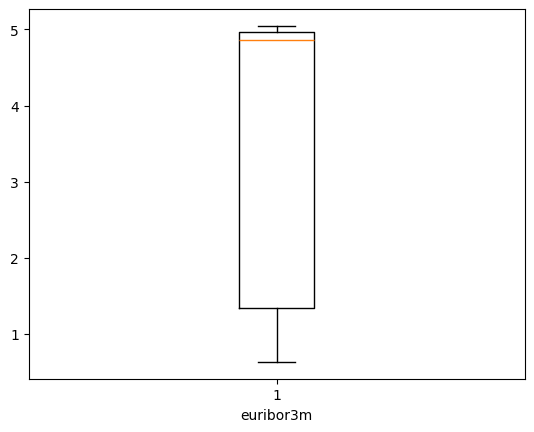

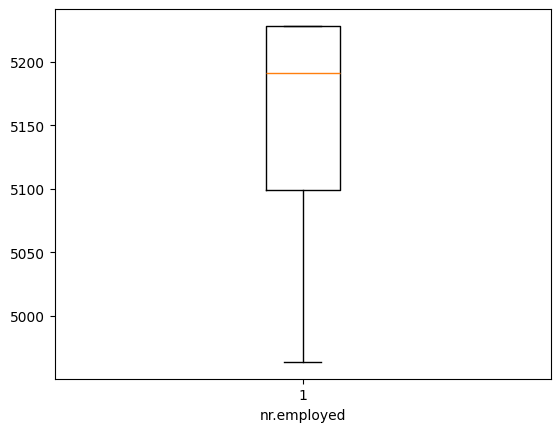

In [95]:
# Identifying Outliers in the Dataset.
for i in df.columns:
  if(df[i].dtypes != 'object'):
    plt.boxplot(df[i])
    plt.xlabel(i)
    plt.show()

In [96]:
# Removing the outliers from the dataset.
q1=df['duration'].quantile(0.25)
q3=df['duration'].quantile(0.75)
IQR=q3-q1
UL=q3+1.5*IQR
LL=q1-1.5*IQR
df=df[(df['duration']>=LL) & (df['duration']<=UL)]

In [97]:
df.shape

(38214, 21)

### STEP 6.Feature Engineering for Encoding,Scaling,Feature creation.


In [98]:
col_list=list(df.columns)

In [99]:
le = LabelEncoder()

for i in col_list:
  if df[i].dtype == 'object':
    df[i] = le.fit_transform(df[i])
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,3,1,0,0,0,0,1,6,1,261.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57.0,7,1,3,1,0,0,1,6,1,149.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37.0,7,1,3,0,2,0,1,6,1,226.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40.0,0,1,1,0,0,0,1,6,1,151.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56.0,7,1,3,0,0,2,1,6,1,307.0,1.0,999.0,0.0,1,1.1,93.994,-36.4,4.857,5191.0,0


- Now, all columns with the object data type have been converted into numeric data type columns.


In [100]:
# Splitting the dataset.
x = df.drop('y',axis=1)
y = df['y']

In [101]:
lor = LogisticRegression()

In [102]:
#We are using RFE to identify relevant columns for model training.

rfe=RFE(lor)

rfe.fit(x,y)

RFE(estimator=LogisticRegression())

In [103]:
rfe.support_

array([False, False,  True,  True,  True, False, False,  True,  True,
        True, False,  True, False,  True,  True, False, False, False,
        True, False])

In [104]:
selected_indices=[i for i,data in enumerate(rfe.support_) if data==True]
selected_indices

[2, 3, 4, 7, 8, 9, 11, 13, 14, 18]

In [105]:
column_name=x.columns

In [106]:
selected_columns=[column_name[i] for i in selected_indices]
selected_columns

['marital',
 'education',
 'default',
 'contact',
 'month',
 'day_of_week',
 'campaign',
 'previous',
 'poutcome',
 'euribor3m']

In [107]:
x=x.loc[:,['marital',
 'education',
 'default',
 'contact',
 'month',
 'day_of_week',
 'campaign',
 'previous',
 'poutcome',
 'euribor3m']]

- The columns that are relevant to model training.

### STEP 7.Divide the dataset into features (x) and target variable (y) for training the model.


In [119]:
# Splitting the dataset.
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

### STEP 8.Model Selection & Training
- choose algorithms based on problem type.


In [109]:
lor.fit(x_train,y_train)

LogisticRegression()

In [110]:
y_pred=lor.predict(x_test)

In [111]:
pred_df=pd.DataFrame()
pred_df['Actual Value']=y_test
pred_df['Predicted Value']=y_pred

In [112]:
pred_df

,Actual Value,Predicted Value
28200,0,0
17756,0,0
22392,0,0
1500,0,0
21313,0,0
...,...,...
24890,0,0
25884,0,0
18095,0,0
34205,1,0


### STEP 9: Model Evaluation  
- Assessing the performance of the model based on various parameters.

In [113]:
confusion_matrix(y_test,y_pred)

array([[6949,   55],
       [ 493,  146]])

In [114]:
accuracy_score(y_test,y_pred)*100

92.83004055998954

In [115]:
precision_score(y_test,y_pred)

0.7263681592039801

In [116]:
recall_score(y_test,y_pred)

0.22848200312989045

- After building the ML model, we evaluated it and achieved " 92 % accuracy ".

#####  --> Visual representation of the performance using a heatmap.

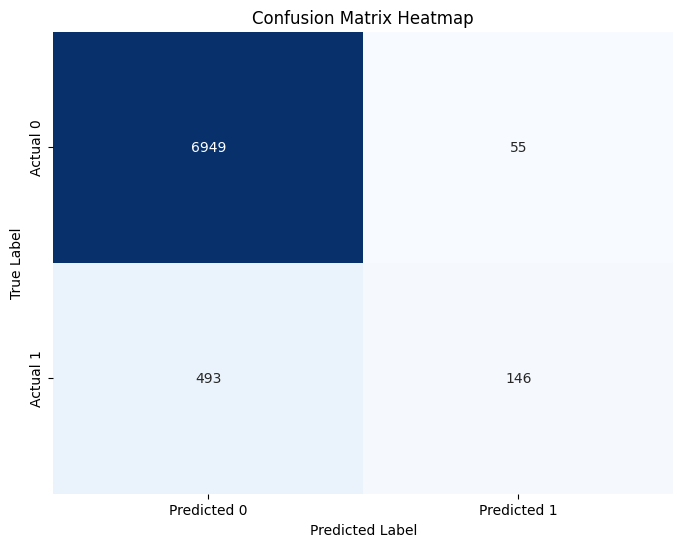

In [118]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()